In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


os.chdir(r"C:\Users\affan\OneDrive\Desktop\Projects\Insurance_prediction")


insu_df = pd.read_csv("dataset/raw_dataset/Dataset.csv")


In [3]:
# checking how many att val's have been missing

for att in insu_df:

    print(f"{att}:{insu_df[att].isnull().sum()}",end = "\n")


ID:0
ID_policy:0
ID_insured:0
period:0
date_effect_insured:0
date_lapse_insured:167181
date_effect_policy:0
date_lapse_policy:174568
year_effect_insured:0
year_lapse_insured:167181
year_effect_policy:0
year_lapse_policy:174568
exposure_time:0
lapse:0
seniority_insured:0
seniority_policy:0
type_policy:0
type_policy_dg:0
type_product:0
reimbursement:0
new_business:0
distribution_channel:0
gender:0
age:0
premium:0
cost_claims_year:0
n_medical_services:0
n_insured_pc:0
n_insured_mun:0
n_insured_prov:0
IICIMUN:10886
IICIPROV:5701
C_H:10886
C_GI:13213
C_II:13213
C_IE_P:13213
C_IE_S:13213
C_IE_T:13213
C_GE_P:13213
C_GE_S:13213
C_GE_T:13213
C_C:10556


In [4]:
insu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228711 entries, 0 to 228710
Data columns (total 42 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    228711 non-null  object 
 1   ID_policy             228711 non-null  int64  
 2   ID_insured            228711 non-null  int64  
 3   period                228711 non-null  int64  
 4   date_effect_insured   228711 non-null  object 
 5   date_lapse_insured    61530 non-null   object 
 6   date_effect_policy    228711 non-null  object 
 7   date_lapse_policy     54143 non-null   object 
 8   year_effect_insured   228711 non-null  int64  
 9   year_lapse_insured    61530 non-null   float64
 10  year_effect_policy    228711 non-null  int64  
 11  year_lapse_policy     54143 non-null   float64
 12  exposure_time         228711 non-null  float64
 13  lapse                 228711 non-null  int64  
 14  seniority_insured     228711 non-null  int64  
 15  

<Axes: >

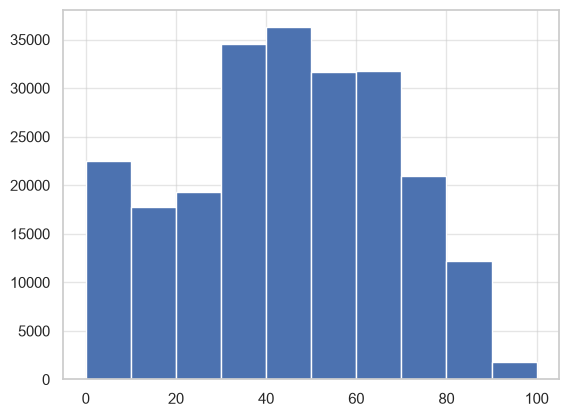

In [273]:
import numpy as np

bins = np.arange(0, insu_df["age"].max()+10 , 10)

insu_df["age"].hist(bins=bins)

<Axes: >

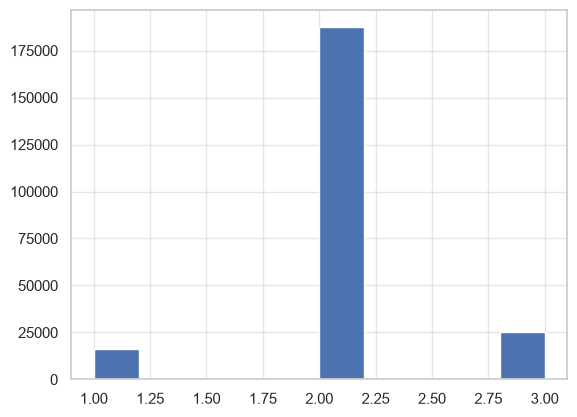

In [277]:


insu_df["lapse"].hist()

In [272]:
# we got all the non null value

for att in insu_df:
    print(f"{att} : {(insu_df[att].isnull().sum()/len(insu_df[att]))*100}",end = "\n")

ID : 0.0
ID_policy : 0.0
ID_insured : 0.0
period : 0.0
date_effect_insured : 0.0
date_lapse_insured : 73.09705261224865
date_effect_policy : 0.0
date_lapse_policy : 76.32689289102842
year_effect_insured : 0.0
year_lapse_insured : 73.09705261224865
year_effect_policy : 0.0
year_lapse_policy : 76.32689289102842
exposure_time : 0.0
lapse : 0.0
seniority_insured : 0.0
seniority_policy : 0.0
type_policy : 0.0
type_policy_dg : 0.0
type_product : 0.0
reimbursement : 0.0
new_business : 0.0
distribution_channel : 0.0
gender : 0.0
age : 0.0
premium : 0.0
cost_claims_year : 0.0
n_medical_services : 0.0
n_insured_pc : 0.0
n_insured_mun : 0.0
n_insured_prov : 0.0
IICIMUN : 4.759718596831809
IICIPROV : 2.492665416180245
C_H : 4.759718596831809
C_GI : 5.777159821783823
C_II : 5.777159821783823
C_IE_P : 5.777159821783823
C_IE_S : 5.777159821783823
C_IE_T : 5.777159821783823
C_GE_P : 5.777159821783823
C_GE_S : 5.777159821783823
C_GE_T : 5.777159821783823
C_C : 4.615431702016956


                      null_count  null_rate
date_lapse_policy         174568  76.326893
year_lapse_policy         174568  76.326893
year_lapse_insured        167181  73.097053
date_lapse_insured        167181  73.097053
C_GE_S                     13213   5.777160
C_GE_T                     13213   5.777160
C_IE_T                     13213   5.777160
C_IE_S                     13213   5.777160
C_IE_P                     13213   5.777160
C_GE_P                     13213   5.777160
C_II                       13213   5.777160
C_GI                       13213   5.777160
C_H                        10886   4.759719
IICIMUN                    10886   4.759719
C_C                        10556   4.615432
IICIPROV                    5701   2.492665
ID                             0   0.000000
ID_policy                      0   0.000000
year_effect_insured            0   0.000000
date_effect_policy             0   0.000000
period                         0   0.000000
date_effect_insured            0

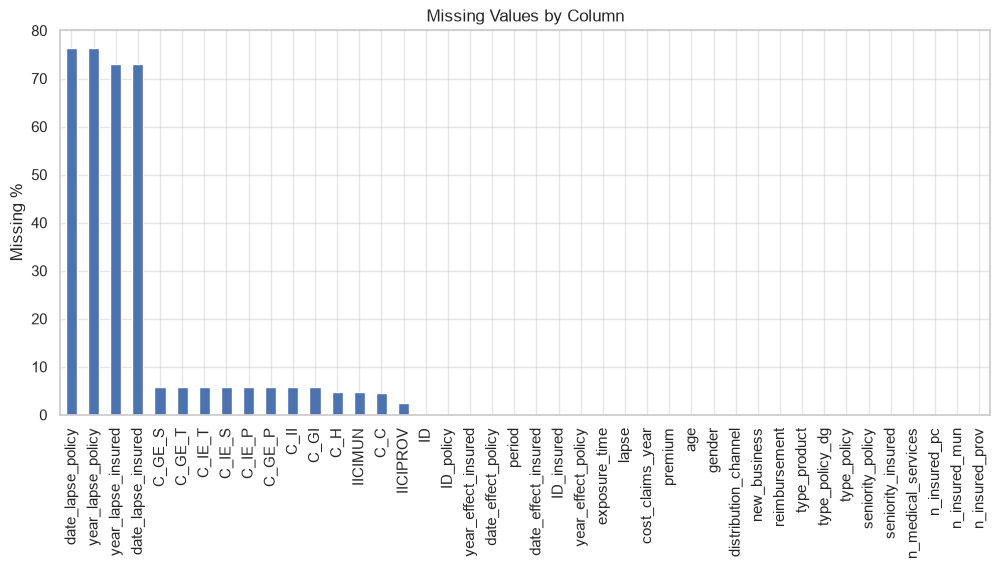

In [279]:

#this gives the details of how much data is missing

null_report = pd.DataFrame({
    "null_count": insu_df.isna().sum(),
    "null_rate": insu_df.isna().mean() * 100
})

null_report = null_report.sort_values(
    "null_rate",
    ascending=False
)

print(null_report)


import matplotlib.pyplot as plt

null_report["null_rate"].plot(kind="bar", figsize=(12,5))

plt.ylabel("Missing %")
plt.title("Missing Values by Column")
plt.show()

In [278]:
insu_df['lapse'].value_counts(normalize=True)

lapse
2    0.818811
3    0.109711
1    0.071479
Name: proportion, dtype: float64

In [61]:
#getting the mean premium for the whole policy

insu_df["mean"] = insu_df.groupby(["ID_policy"])["premium"].transform("mean").sort_values()
insu_df[["ID_policy","mean"]].drop_duplicates()

,ID_policy,mean
0,1,2234.500325
2,2,2098.443333
3,3,1449.212850
7,4,2389.199333
8,5,1974.070533
...,...,...
228701,45158,522.972000
228702,45159,451.200118
228705,45160,581.748774
228706,45161,627.435000


In [20]:
insu_df.columns

Index(['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured',
       'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy',
       'year_effect_insured', 'year_lapse_insured', 'year_effect_policy',
       'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insured',
       'seniority_policy', 'type_policy', 'type_policy_dg', 'type_product',
       'reimbursement', 'new_business', 'distribution_channel', 'gender',
       'age', 'premium', 'cost_claims_year', 'n_medical_services',
       'n_insured_pc', 'n_insured_mun', 'n_insured_prov', 'IICIMUN',
       'IICIPROV', 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_S', 'C_IE_T',
       'C_GE_P', 'C_GE_S', 'C_GE_T', 'C_C', 'dele'],
      dtype='str')

In [52]:
#just checking if the max of insured years is same or not

temp = pd.to_datetime(insu_df["date_effect_insured"],dayfirst=True)

diff = (
    temp.max()
    - temp.min()
)

diff.days/365

86.59726027397261

In [104]:
#this is to find how many people are categorized in a certain group

insu_df.groupby(by = ["lapse"])["ID"].nunique()

lapse
1    16348
2    80623
3    25092
Name: ID, dtype: int64

In [225]:
insu_df[insu_df["date_lapse_insured"].notna() | insu_df["date_lapse_policy"].notna()]


,ID,ID_policy,ID_insured,period,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy,year_effect_insured,year_lapse_insured,year_effect_policy,year_lapse_policy,exposure_time,lapse,seniority_insured,seniority_policy,type_policy,type_policy_dg,type_product,reimbursement,new_business,distribution_channel,gender,age,premium,cost_claims_year,n_medical_services,n_insured_pc,n_insured_mun,n_insured_prov,IICIMUN,IICIPROV,C_H,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T,C_C
0,1_1,1,1,2017,15-06-1993,20-12-2017,15-06-1993,NaN,1993,2017.0,1993,NaN,0.969749,1,24,24,I,I,S,No,No,A,M,83,2923.320000,8242.62,32,27,27,7467,54.66,10.49,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
10,6_1,6,1,2017,01-07-1993,31-12-2017,01-07-1993,31-12-2017,1993,2017.0,1993,2017.0,1.000000,3,24,24,I,I,P,Yes,No,I,M,73,1936.170000,1303.56,24,130,130,7467,22.20,10.49,H2,95.0,60.0,31.0,56.0,52.0,9.0,19.0,94.0,C6
11,6_2,6,2,2017,01-07-1993,31-12-2017,01-07-1993,31-12-2017,1993,2017.0,1993,2017.0,1.000000,3,24,24,I,I,P,Yes,No,I,F,69,3640.380000,3270.38,59,2518,4393,2518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,16_1,16,1,2017,20-08-1993,01-01-2017,20-08-1993,31-03-2017,1993,2017.0,1993,2017.0,0.002626,1,24,24,I,I,S,No,No,I,M,82,2837.640000,0.00,0,166,3193,7467,17.13,10.49,H6,100.0,96.0,21.0,8.0,91.0,5.0,1.0,100.0,C6
34,16_2,16,2,2017,20-08-1993,31-03-2017,20-08-1993,31-03-2017,1993,2017.0,1993,2017.0,0.246347,1,24,24,I,I,S,No,No,I,F,69,1589.160000,0.00,0,166,3193,7467,17.13,10.49,H6,100.0,96.0,21.0,8.0,91.0,5.0,1.0,100.0,C6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228566,45094_1,45094,1,2019,15-12-2019,31-12-2019,15-12-2019,31-12-2019,2019,2019.0,2019,2019.0,1.000000,3,0,0,I,I,S,No,Yes,I,F,39,464.937000,0.00,0,37,74,8114,0.38,1.26,H6,72.0,24.0,33.0,99.0,16.0,9.0,95.0,63.0,C1
228567,45094_2,45094,2,2019,15-12-2019,31-12-2019,15-12-2019,31-12-2019,2019,2019.0,2019,2019.0,1.000000,3,0,0,I,I,S,No,Yes,I,M,13,432.525000,0.00,0,37,74,8114,0.38,1.26,H6,72.0,24.0,33.0,99.0,16.0,9.0,95.0,63.0,C1
228604,45117_1,45117,1,2019,15-12-2019,31-12-2019,15-12-2019,31-12-2019,2019,2019.0,2019,2019.0,1.000000,3,0,0,I,I,S,No,Yes,D,F,16,547.553676,0.00,0,50,1144,3300,1.44,1.29,H6,90.0,49.0,50.0,43.0,57.0,15.0,10.0,95.0,C3
228627,45129_1,45129,1,2019,15-12-2019,31-12-2019,15-12-2019,31-12-2019,2019,2019.0,2019,2019.0,1.000000,3,0,0,I,I,S,No,Yes,I,M,49,639.480000,0.00,0,10,10,1017,0.29,0.54,H4,41.0,8.0,91.0,90.0,8.0,46.0,75.0,48.0,C3


In [144]:
insu_df.columns

Index(['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured',
       'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy',
       'year_effect_insured', 'year_lapse_insured', 'year_effect_policy',
       'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insured',
       'seniority_policy', 'type_policy', 'type_policy_dg', 'type_product',
       'reimbursement', 'new_business', 'distribution_channel', 'gender',
       'age', 'premium', 'cost_claims_year', 'n_medical_services',
       'n_insured_pc', 'n_insured_mun', 'n_insured_prov', 'IICIMUN',
       'IICIPROV', 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_S', 'C_IE_T',
       'C_GE_P', 'C_GE_S', 'C_GE_T', 'C_C'],
      dtype='str')

In [330]:
import pandas as pd

numeric_cols = ["age", "premium", "cost_claims_year", "n_medical_services",
                 "exposure_time", "seniority_insured", "seniority_policy"]
print("\nDescribe numeric cols:\n", insu_df[numeric_cols].describe().T)




Describe numeric cols:
                        count        mean          std    min     25%       50%        75%         max
age                 228711.0   44.412333    23.080977   0.00   29.00   45.0000    63.0000     99.0000
premium             228711.0  852.013382   556.657137  33.33  539.58  752.7126  1024.1400  22318.0488
cost_claims_year    228711.0  587.663381  1639.665775   0.00    0.00  185.6400   542.4231  87000.9000
n_medical_services  228711.0   16.812291    28.228931   0.00    0.00    6.0000    23.0000   3094.0000
exposure_time       228711.0    0.935408     0.232527   0.00    1.00    1.0000     1.0000      1.0000
seniority_insured   228711.0   12.776714    13.014838   0.00    2.00    9.0000    22.0000     86.0000
seniority_policy    228711.0   13.696464    13.948242   0.00    2.00   10.0000    23.0000     87.0000


[]

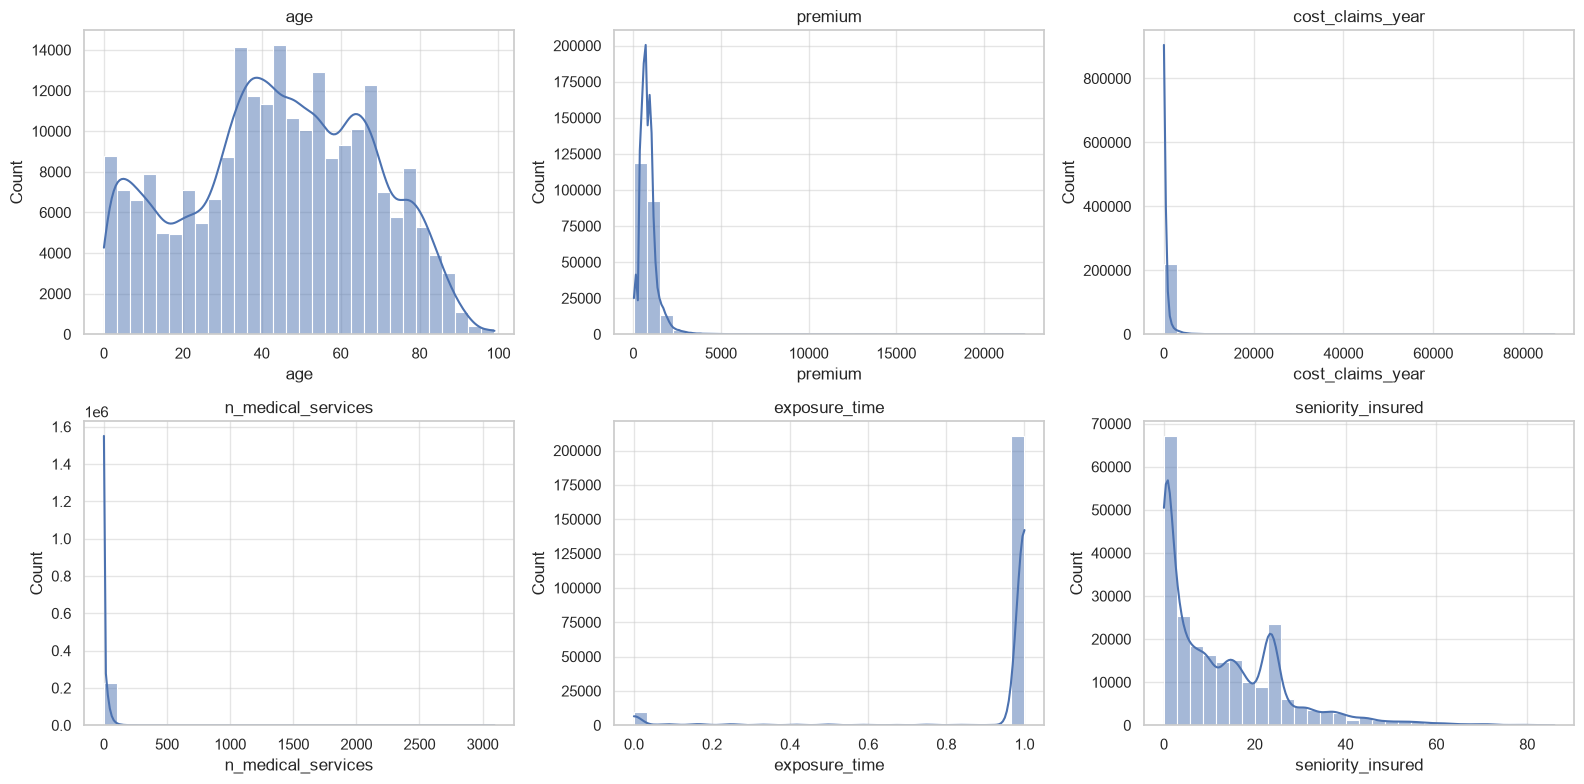

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3)
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(insu_df[col].dropna(), kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.plot()


In [285]:
corr_lis = list(insu_df.dtypes[(insu_df.dtypes == "float64") | (insu_df.dtypes == "int64")].keys())


In [286]:
corr_lapse=insu_df[corr_lis].corr()["lapse"]

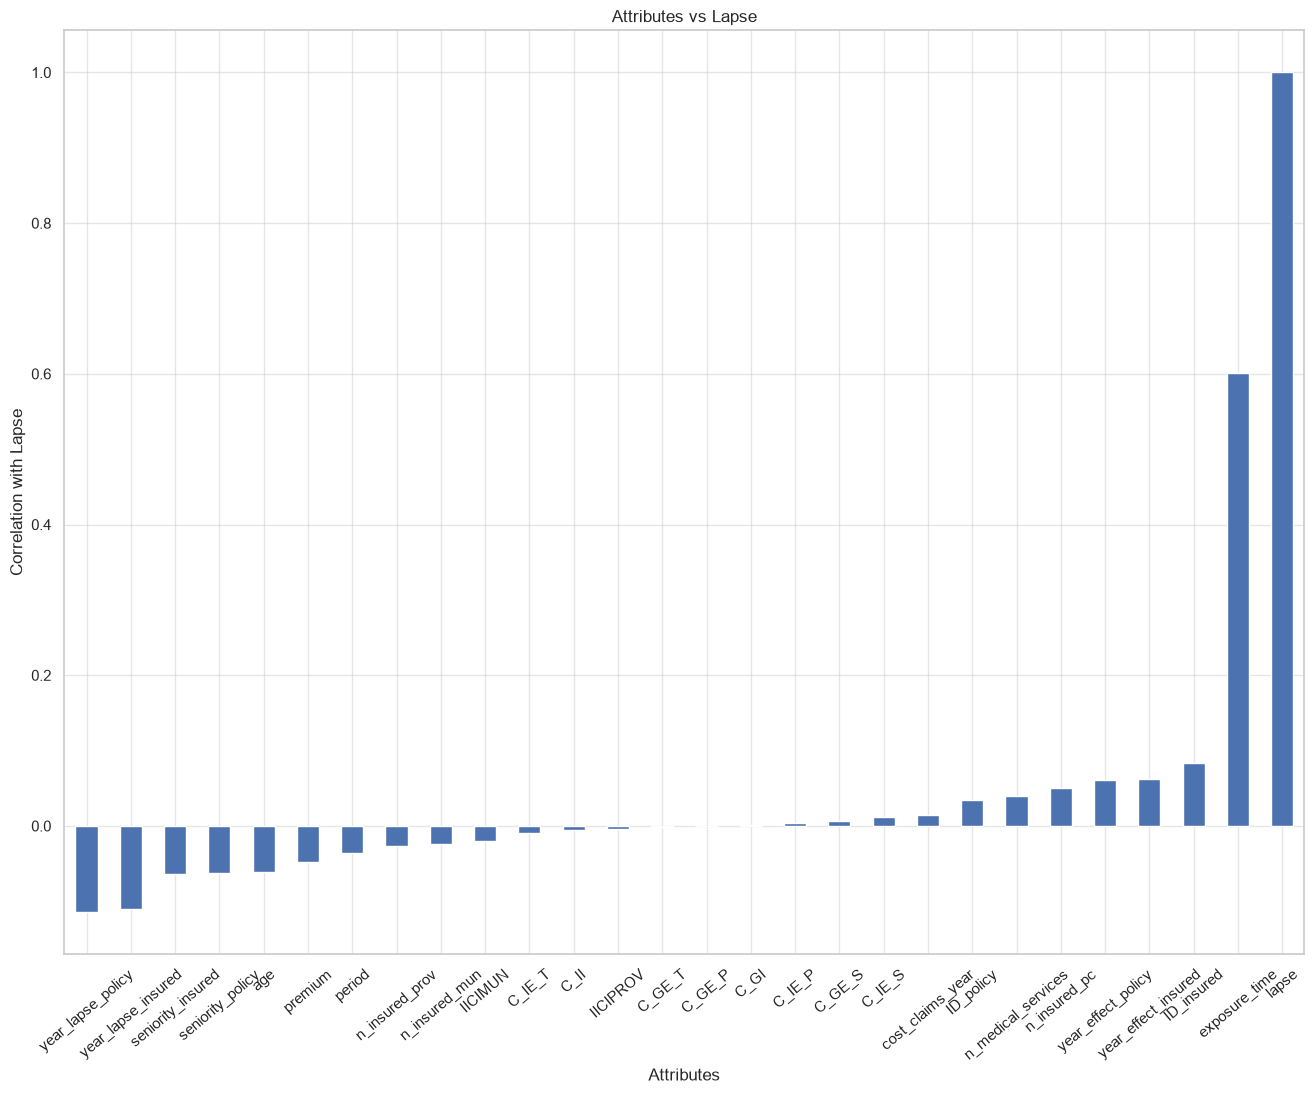

In [284]:
corr_lapse.sort_values(ascending=True).plot(
    kind="bar",
    figsize=(16, 12)
)

plt.xlabel("Attributes")
plt.ylabel("Correlation with Lapse")
plt.title("Attributes vs Lapse")
plt.xticks(rotation=40)
plt.show()

In [204]:
insu_df.date_effect_insured

0         15-06-1993
1         15-06-1993
2         16-06-1993
3         15-06-1993
4         15-06-1993
             ...    
228706    15-12-2019
228707    15-12-2019
228708    15-12-2019
228709    15-12-2019
228710    15-12-2019
Name: date_effect_insured, Length: 228711, dtype: str

In [267]:
#check if all the dates are of the same date type

lis = ['date_effect_insured',
 'date_lapse_insured',
 'date_effect_policy',
 'date_lapse_policy']

for colo in lis:

    valid = pd.to_datetime(
        insu_df[colo],
        format="%d-%m-%Y",
        errors="coerce"
        ).notna()

    if insu_df[~valid].count().loc[colo] != 0:
        print(colo)


In [323]:

#these attributes can be helpful in find the relation between different attributes

insu_df["loss_ratio"] = insu_df["cost_claims_year"] / insu_df["premium"].replace(0, np.nan)
insu_df["cost_per_service"] = insu_df["cost_claims_year"] / insu_df["n_medical_services"].replace(0, np.nan)

In [324]:
len(insu_df.columns)

44

[]

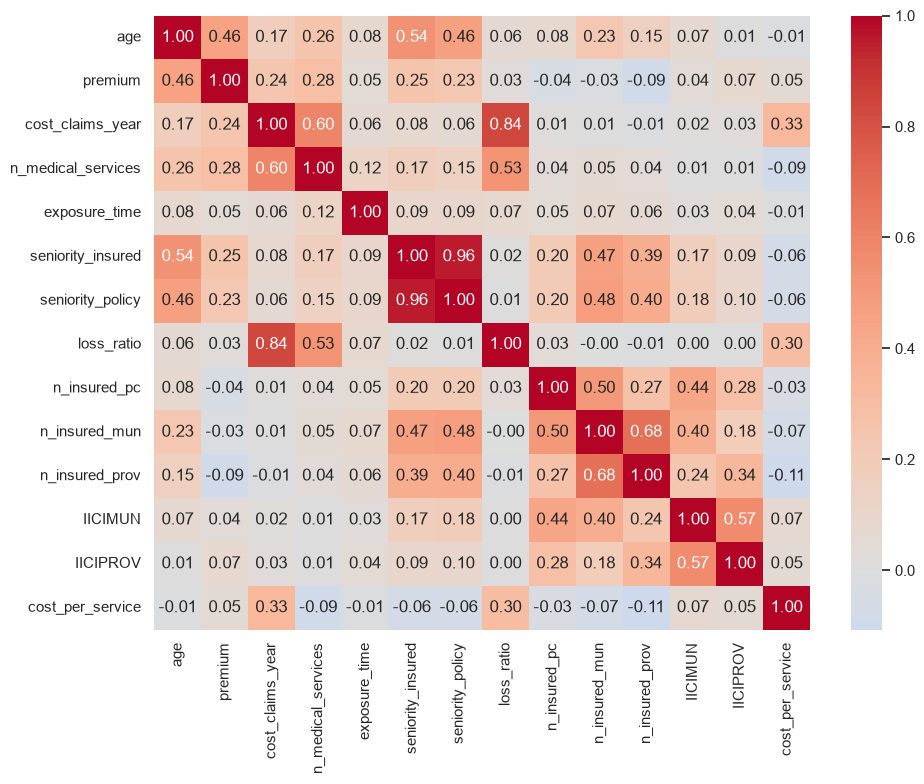

In [335]:
corr_cols = numeric_cols + ["loss_ratio", "n_insured_pc", "n_insured_mun",
                             "n_insured_prov", "IICIMUN", "IICIPROV","cost_per_service"]
corr = insu_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.plot()


In [49]:


trend = insu_df.groupby("period").agg(

    n_policies = ("ID", "count"),
    mean_premium = ("premium","mean"),
    mean_claims=("cost_claims_year", "mean")
)

trend




,n_policies,mean_premium,mean_claims
period,,,
2017,78459,833.492601,589.083957
2018,73970,858.088254,603.768225
2019,76282,865.171973,570.585535


In [27]:
from sklearn.preprocessing import StandardScaler

colo = trend.columns

obj = StandardScaler()

trend[colo] = obj.fit_transform(trend[colo])


In [32]:
trend.shape

(3, 3)

In [34]:
trend.median()

n_policies      0.024551
mean_premium    0.429981
mean_claims     0.093645
dtype: float64

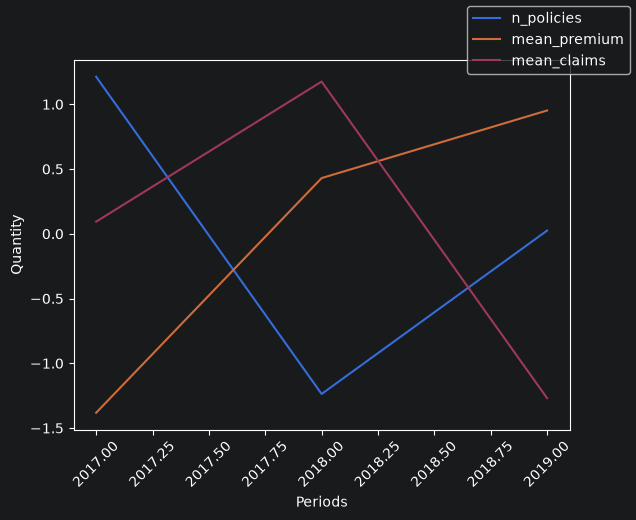

In [47]:
trend.plot(legend=False)
plt.xlabel("Periods")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.figlegend()

In [57]:
list(insu_df.dtypes.loc[(insu_df.dtypes == "int") | (insu_df.dtypes == "float")].index)

['ID_policy',
 'ID_insured',
 'period',
 'year_effect_insured',
 'year_lapse_insured',
 'year_effect_policy',
 'year_lapse_policy',
 'exposure_time',
 'lapse',
 'seniority_insured',
 'seniority_policy',
 'age',
 'premium',
 'cost_claims_year',
 'n_medical_services',
 'n_insured_pc',
 'n_insured_mun',
 'n_insured_prov',
 'IICIMUN',
 'IICIPROV',
 'C_GI',
 'C_II',
 'C_IE_P',
 'C_IE_S',
 'C_IE_T',
 'C_GE_P',
 'C_GE_S',
 'C_GE_T']

In [58]:
insu_df.nunique()

ID                      100453
ID_policy                45162
ID_insured                1467
period                       3
date_effect_insured       5332
date_lapse_insured         655
date_effect_policy        3268
date_lapse_policy          395
year_effect_insured         87
year_lapse_insured           3
year_effect_policy          88
year_lapse_policy            3
exposure_time              480
lapse                        3
seniority_insured           87
seniority_policy            88
type_policy                  2
type_policy_dg               6
type_product                 4
reimbursement                2
new_business                 2
distribution_channel         3
gender                       2
age                        100
premium                  44141
cost_claims_year         56956
n_medical_services         372
n_insured_pc               336
n_insured_mun              279
n_insured_prov             139
IICIMUN                   1078
IICIPROV                    91
C_H     

In [90]:
insu_df.groupby(["ID_policy","ID_insured"]).agg("count").sort_values(["ID_policy","ID_insured"],ascending=[True,True])

ID  period  date_effect_insured  date_lapse_insured  \
ID_policy ID_insured                                                        
1         1            1       1                    1                   1   
          2            3       3                    3                   0   
2         1            3       3                    3                   0   
3         3            3       3                    3                   0   
          5            3       3                    3                   0   
...                   ..     ...                  ...                 ...   
45161     1            1       1                    1                   1   
45162     1            1       1                    1                   0   
          2            1       1                    1                   0   
          3            1       1                    1                   0   
          4            1       1                    1                   0   

                      date_effect_policy  date_lapse_policy  \
ID_policy ID_insured                                          
1         1                            1                  0   
          2                            3                  0   
2         1                            3                  0   
3         3                            3                  0   
          5                            3                  0   
...                                  ...                ...   
45161     1                            1                  1   
45162     1                            1                  0   
          2                            1                  0   
          3                            1                  0   
          4                            1                  0   

                      year_effect_insured  year_lapse_insured  \
ID_policy ID_insured                                            
1         1                             1                   1   
          2                             3                   0   
2         1                             3                   0   
3         3                             3                   0   
          5                             3                   0   
...                                   ...                 ...   
45161     1                             1                   1   
45162     1                             1                   0   
          2                             1                   0   
          3                             1                   0   
          4                             1                   0   

                      year_effect_policy  year_lapse_policy  ...  C_H  C_GI  \
ID_policy ID_insured                                         ...              
1         1                            1                  0  ...    1     1   
          2                            3                  0  ...    3     3   
2         1                            3                  0  ...    3     3   
3         3                            3                  0  ...    0     0   
          5                            3                  0  ...    3     3   
...                                  ...                ...  ...  ...   ...   
45161     1                            1                  1  ...    1     1   
45162     1                            1                  0  ...    1     1   
          2                            1                  0  ...    1     1   
          3                            1                  0  ...    1     1   
          4                            1                  0  ...    1     1   

                      C_II  C_IE_P  C_IE_S  C_IE_T  C_GE_P  C_GE_S  C_GE_T  \
ID_policy ID_insured                                                         
1         1              1       1       1       1       1       1       1   
          2              3       3       3       3       3       3       3   
2         1   

In [85]:
insu_df[insu_df["ID"] == "9_1"].T

,19,78475,152445
ID,9_1,9_1,9_1
ID_policy,9,9,9
ID_insured,1,1,1
period,2017,2018,2019
date_effect_insured,01-08-1993,01-08-1993,01-08-1993
date_lapse_insured,NaN,NaN,NaN
date_effect_policy,01-08-1993,01-08-1993,01-08-1993
date_lapse_policy,NaN,NaN,NaN
year_effect_insured,1993,1993,1993
year_lapse_insured,NaN,NaN,NaN
